In [18]:
import numpy as np
import pandas as pd
import utils
from models import AnnLassoRegression
from tqdm import tqdm
import time

In [ ]:
pesr_history = {i: [] for i in range(1, 18)}
model = AnnLassoRegression(warm_start=False, last_ista=30000)

for i in tqdm(range(1, 18), desc="Number of features progress"):
    for j in range(1,5):
        X_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-y.csv", header = None)

        features = pd.read_csv(f"dataSets/dataSets{j}/s{i}/important_inds.csv")
        features = features.values.flatten()

        model.fit(X_train, y_train, print_epochs=False)
        pesr_history[i].append(model.results_analysis(X_test, y_test, features)['exact_recovery'])
    print(pesr_history[i])

In [ ]:
pesr_history2 = {i: [] for i in range(1, 18)}
model = AnnLassoRegression(warm_start=False, last_ista=30000, loss_type=2)

for i in tqdm(range(1, 18), desc="Number of features progress"):
    for j in range(1,5):
        X_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-y.csv", header = None)

        features = pd.read_csv(f"dataSets/dataSets{j}/s{i}/important_inds.csv")
        features = features.values.flatten()

        model.fit(X_train, y_train, print_epochs=False)
        pesr_history2[i].append(model.results_analysis(X_test, y_test, features)['exact_recovery'])
    print(pesr_history2[i])

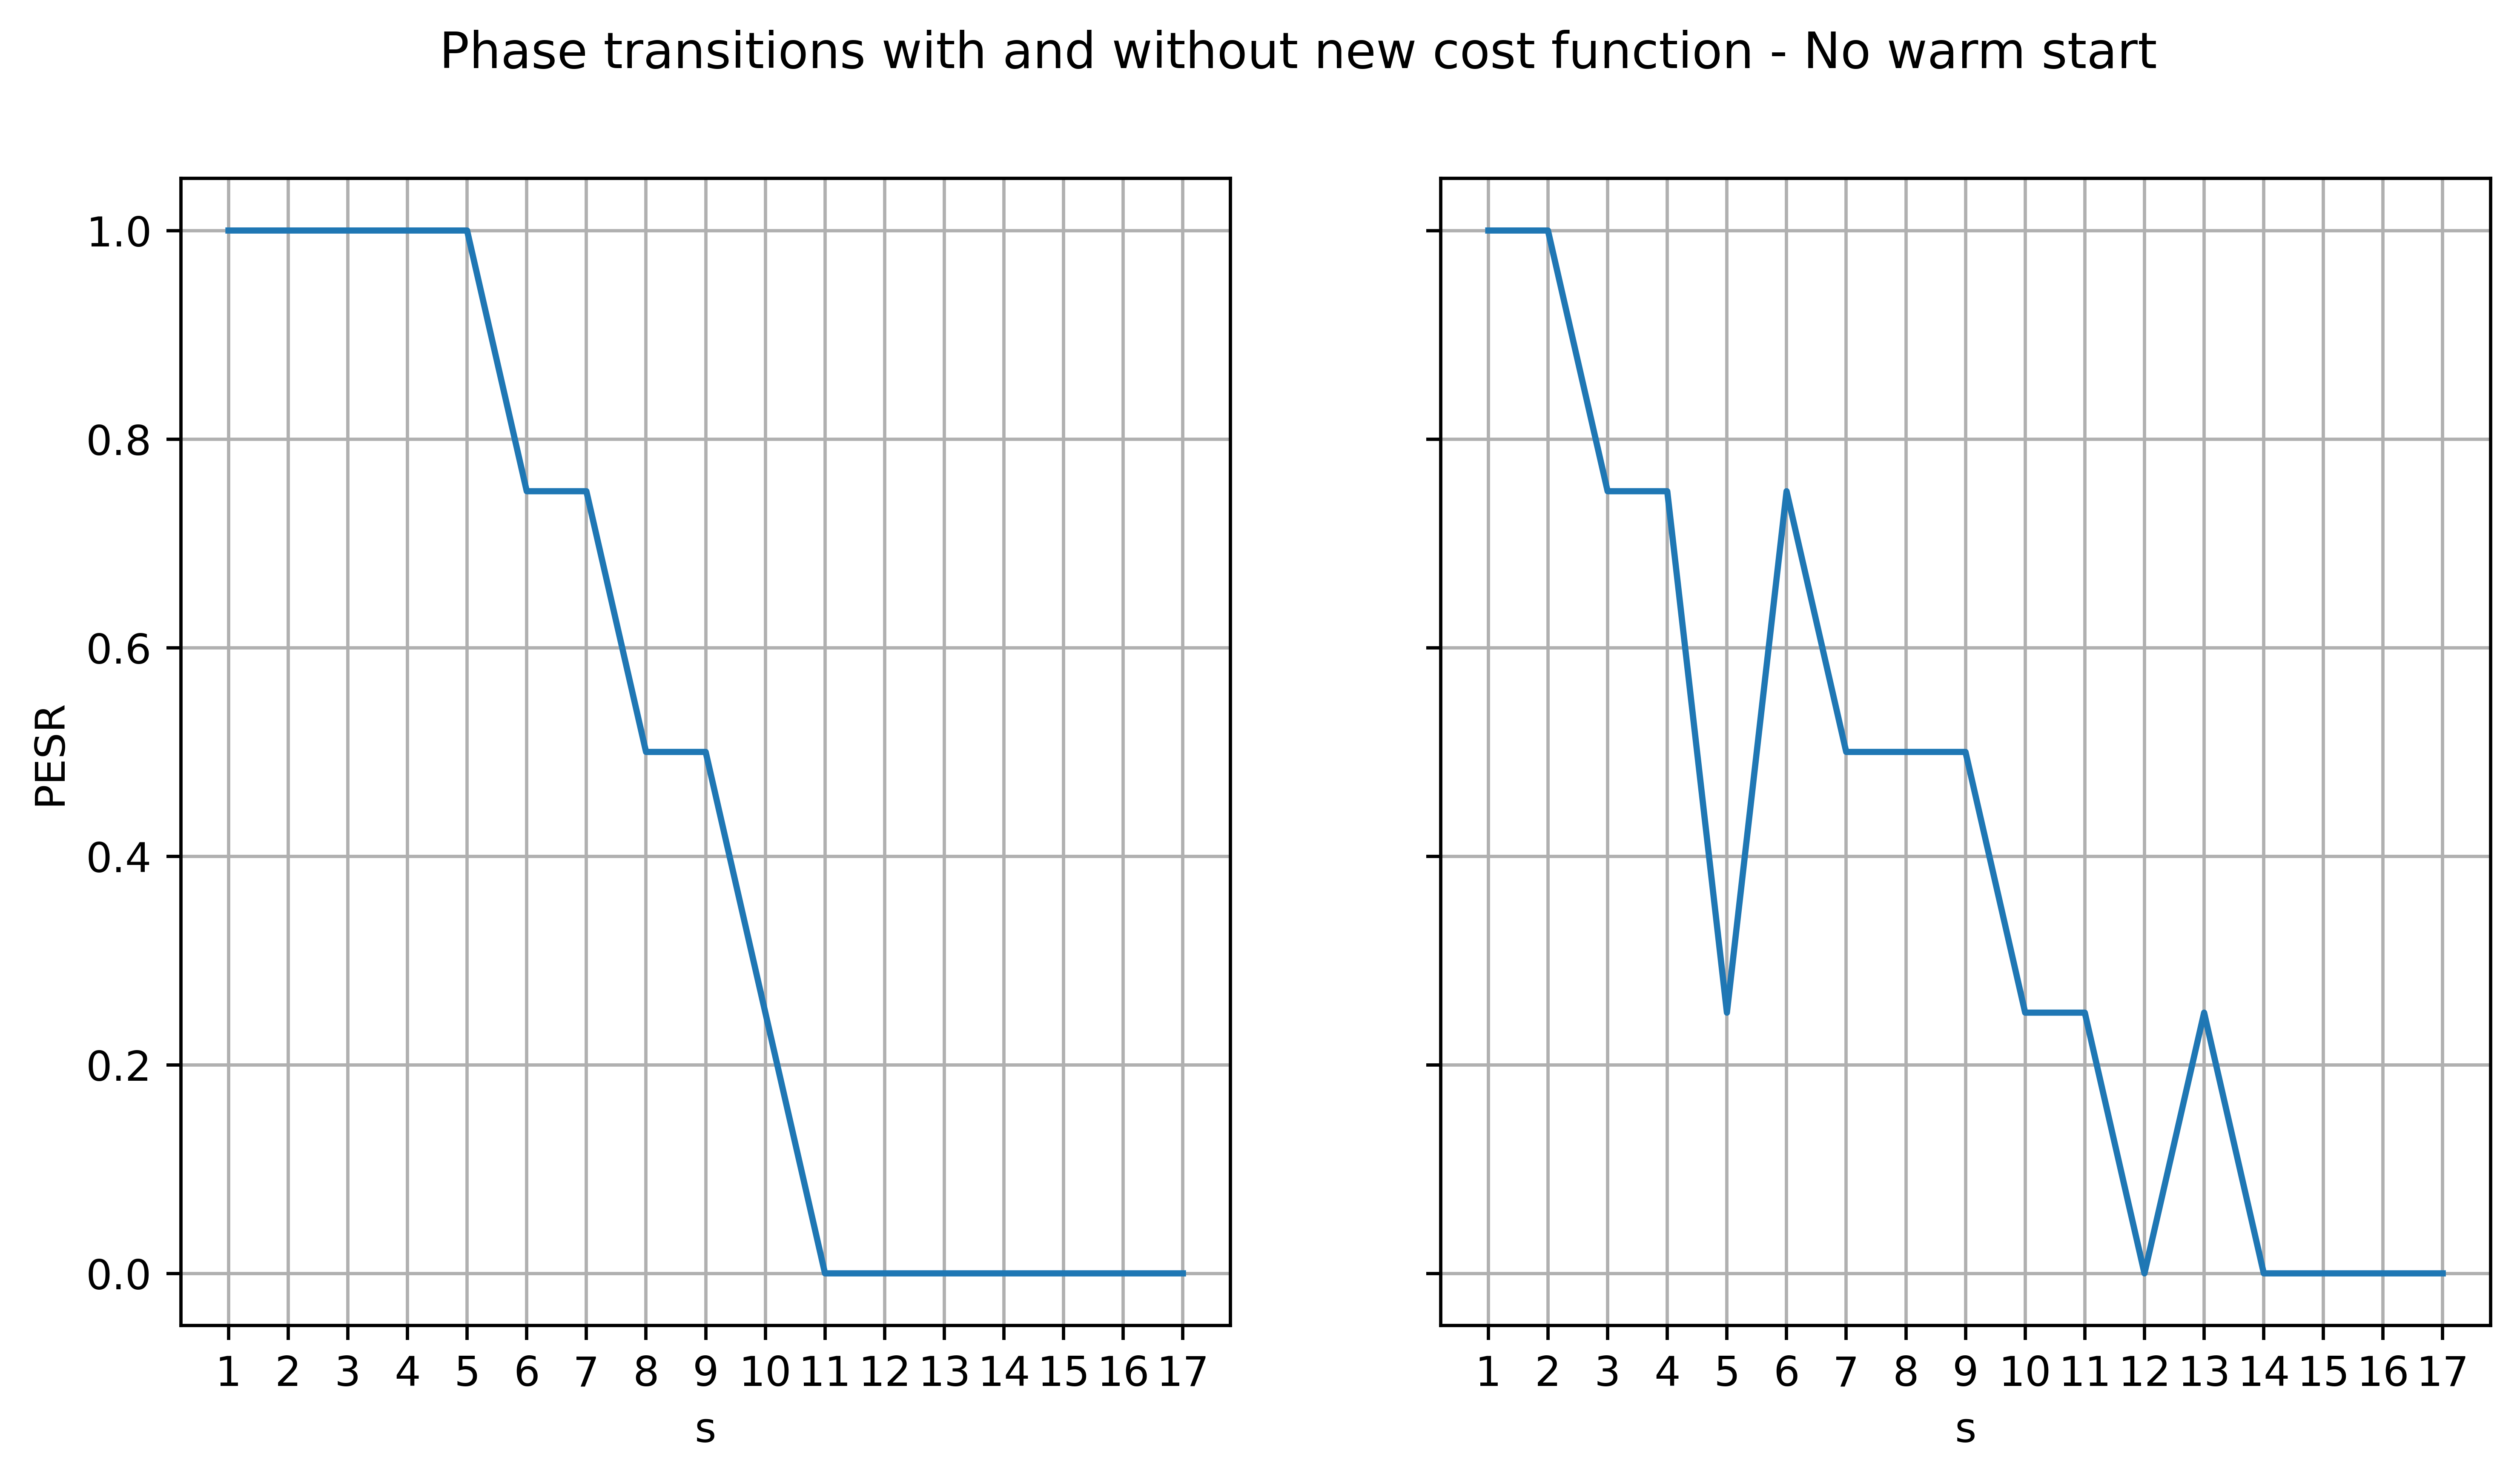

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, dpi=700, sharey=True, figsize=(10, 5))
fig.suptitle('Phase transitions with and without new cost function - No warm start')

ran = np.arange(1, 18)
mean_std_cost = [np.mean(pesr_history[i]) for i in ran]
mean_new_cost = [np.mean(pesr_history2[i]) for i in ran]

ax1.set_ylabel("PESR")
ax1.set_xlabel("s")
ax2.set_xlabel("s")
ax1.plot(ran, mean_new_cost)
ax2.plot(ran, mean_std_cost)

for ax in fig.get_axes():
    ax.label_outer()
    ax.set_xticks(np.arange(1, 18))
    ax.grid(True)

plt.show()

In [ ]:
pesr_history_new_cost= {i: [] for i in range(1, 18)}
pesr_history_old_cost= {i: [] for i in range(1, 18)}
model_new_cost = AnnLassoRegression(warm_start=False, last_ista=30000, loss_type=2)
model_old_cost = AnnLassoRegression(warm_start=True, one_ista=True, last_ista=30000, loss_type=1)
new_cost_times, old_cost_times = [],[]

for i in tqdm(range(1, 18), desc="Number of features progress"):
    for j in range(1,5):
        X_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-y.csv", header = None)

        features = pd.read_csv(f"dataSets/dataSets{j}/s{i}/important_inds.csv")
        features = features.values.flatten()

        t = time.time()
        model_new_cost.fit(X_train, y_train, print_epochs=False)
        new_cost_times.append(time.time() - t)
        t=time.time()
        model_old_cost.fit(X_train, y_train, print_epochs=False)
        old_cost_times.append(time.time() - t)

        pesr_history_new_cost[i].append(model_new_cost.results_analysis(X_test, y_test, features)['exact_recovery'])
        pesr_history_old_cost[i].append(model_old_cost.results_analysis(X_test, y_test, features)['exact_recovery'])

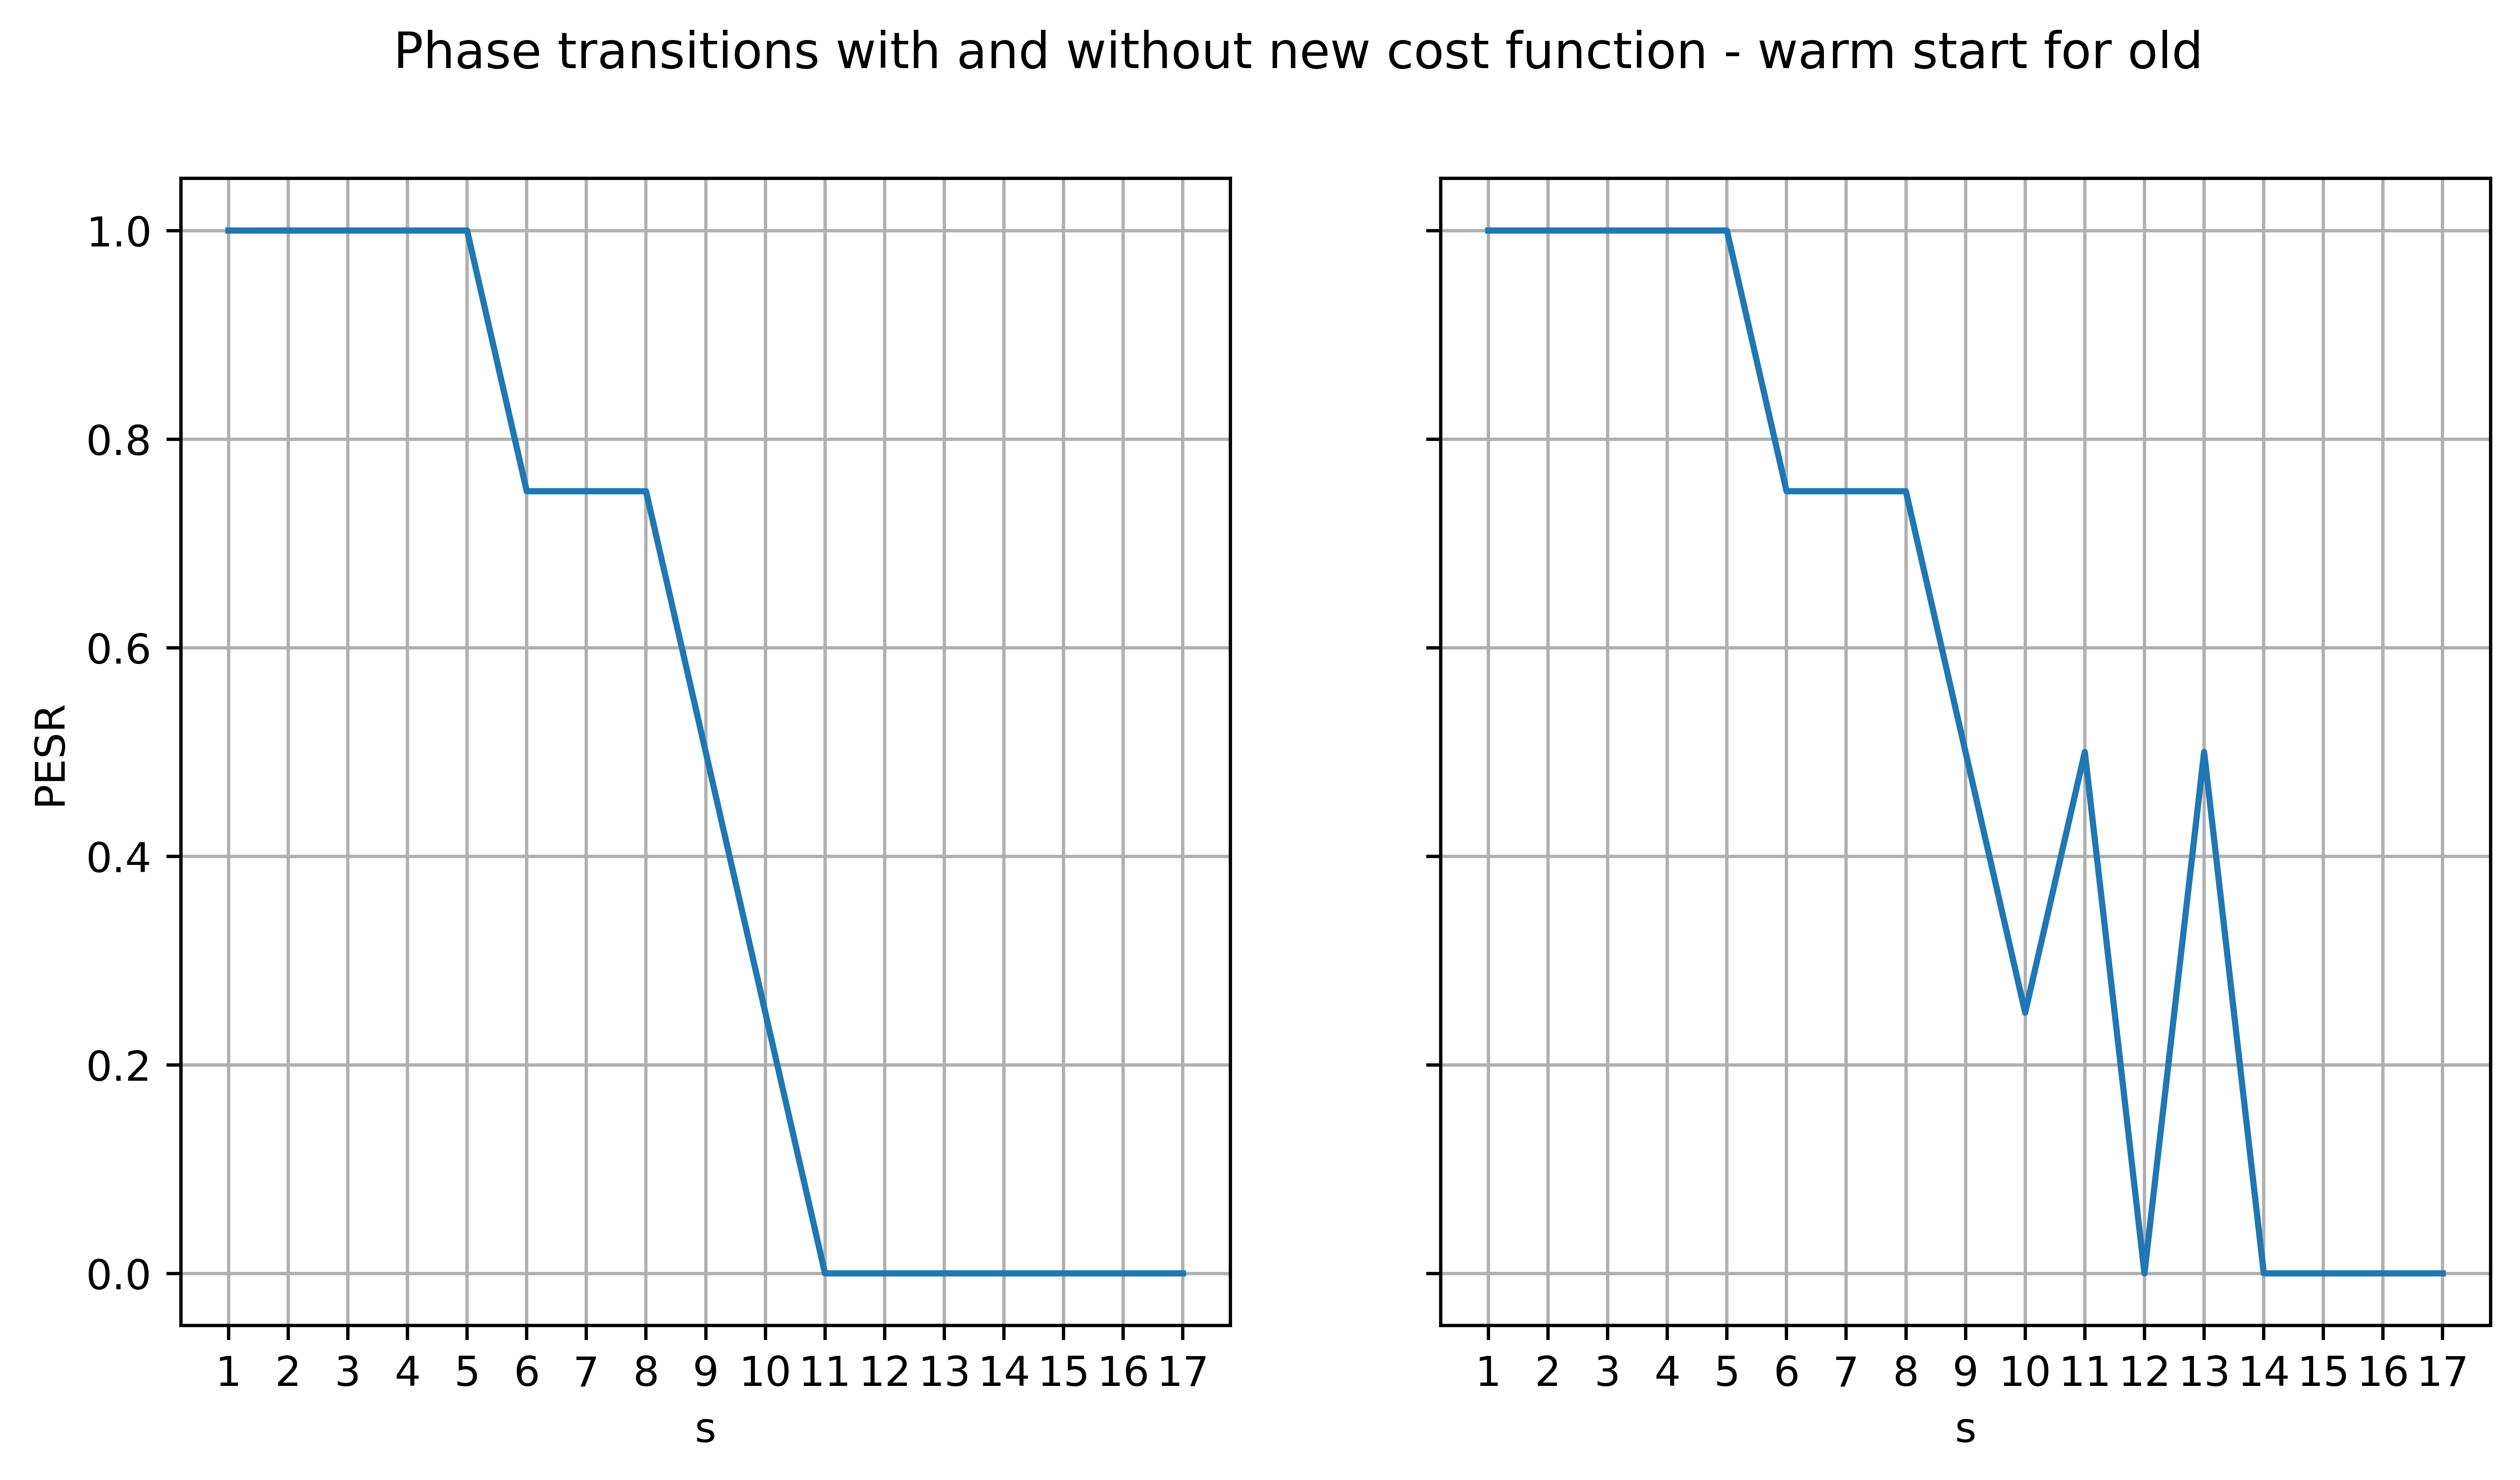

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, dpi=700, sharey=True, figsize=(10, 5))
fig.suptitle('Phase transitions with and without new cost function - warm start for old')

ran = np.arange(1, 18)
mean_std_cost = [np.mean(pesr_history_old_cost[i]) for i in ran]
mean_new_cost = [np.mean(pesr_history_new_cost[i]) for i in ran]

ax1.set_ylabel("PESR")
ax1.set_xlabel("s")
ax2.set_xlabel("s")
ax1.plot(ran, mean_new_cost)
ax2.plot(ran, mean_std_cost)

for ax in fig.get_axes():
    ax.label_outer()
    ax.set_xticks(np.arange(1, 18))
    ax.grid(True)

plt.show()

In [22]:
print(np.mean(new_cost_times), np.mean(old_cost_times))

19.898397589431088 35.62154645779554
